# **Capstone Project: [Deteksi Penyakit pada Tanaman Kelapa Sawit]**
**ID Group:** LAI25-RM112

**Anggota Kelompok:**
- A200YBF418_Refanda Surya Saputra - A200YBF418@devacademy.id
- A270YAF435_Risky Fahriza - A270YAF435@devacademy.id
- A528YBF449_Sebastian Luth Hasibuan - A528YBF449@devacademy.id
- A184YBF450_Sefza Auma Alam - A184YBF450@devacademy.id

## **Import Libraries/Packages**

In [2]:
import os
import random
import shutil
import warnings
import zipfile

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import tensorflow as tf
from keras import Model, layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.layers import InputLayer, Conv2D, MaxPooling2D, Dense, Dropout, BatchNormalization, \
    GlobalAveragePooling2D, AveragePooling2D
from tensorflow.keras.models import Sequential, Model, load_model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import TFSMLayer, Input, Flatten
from tensorflow.keras.callbacks import Callback
from tensorflow.saved_model import save
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2

from PIL import Image
from skimage import io
from skimage import img_as_ubyte
from skimage.exposure import adjust_gamma
from skimage.transform import rotate, AffineTransform, warp
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

from tqdm.notebook import tqdm as tq

import gdown
from google.colab import drive
from IPython.display import FileLink

warnings.simplefilter(action='ignore', category=FutureWarning)

print(tf.__version__)

2.18.0


## **Loading Data**

### **Preparation Data**

#### Using Google Colab

In [ ]:
# Mounting dari google drive
drive.mount('/content/drive')

# Mengakses dataset di google drive
dataset_path = '/content/drive/My Drive/Capstone LAI25-RM112/Dataset/palm-disease-dataset.zip'

# Ekstrak dataset
with zipfile.ZipFile(dataset_path, 'r') as zip_file:
    zip_file.extractall('/content/dataset')

#### Using Local Device

In [2]:
# Ketika menggunakan IDE lokal
file_id = "1c9iWUpGHYl-eq057RheOT6q2-hcpj9F4"
url = f"https://drive.google.com/uc?id={file_id}"

gdown.download(url, 'palm-disease-dataset.zip', quiet=False)

# Unzip berkas yang telah diuduh dari google drive
with zipfile.ZipFile('palm-disease-dataset.zip', 'r') as zip_file:
    zip_file.extractall()

Downloading...
From (original): https://drive.google.com/uc?id=1c9iWUpGHYl-eq057RheOT6q2-hcpj9F4
From (redirected): https://drive.google.com/uc?id=1c9iWUpGHYl-eq057RheOT6q2-hcpj9F4&confirm=t&uuid=6672ab3c-9b83-4f34-8381-a2537fd4c3a9
To: /kaggle/working/palm-disease-dataset.zip
100%|██████████| 779M/779M [00:10<00:00, 73.9MB/s] 


'palm-disease-dataset.zip'

#### Using Kaggle Notebook

In [3]:
# Ketika menggunakan Kaggle Notebook
kaggle_input_path = '/kaggle/input/palm-oil-disease-dataset/palm-disease-dataset'

kaggle_output_path = '/kaggle/working/palm-disease-dataset'

if not os.path.exists(kaggle_output_path):
    os.makedirs(kaggle_output_path)

try:
    shutil.copytree(kaggle_input_path, kaggle_output_path, dirs_exist_ok=True)
    print(f"Berhasil menyalin dataset dari '{kaggle_input_path}' ke {kaggle_output_path}")
except Exception as e:
    print(f"Unexpected error: {e}")

Berhasil menyalin dataset dari '/kaggle/input/palm-oil-disease-dataset/palm-disease-dataset' ke /kaggle/working/palm-disease-dataset


### **Checking Dataset**

In [4]:
# Mengecek label pada dataset

# Ketika menggunakan kaggle, hapus komentar pada baris kode di bawah ini
palm_disease_path = "/kaggle/working/palm-disease-dataset"

# Ketika menggunakan google colab atau lokal device hapus komentar pada baris kode di bawah ini
#palm_disease_path = "/dataset/palm-disease-dataset"

# Menyimpan label
list_label = os.listdir(palm_disease_path)

# Menampilkan list label
list_label

['Magnesium Deficiency', 'Healthy', 'Scale Insect', 'Fungal Disease']

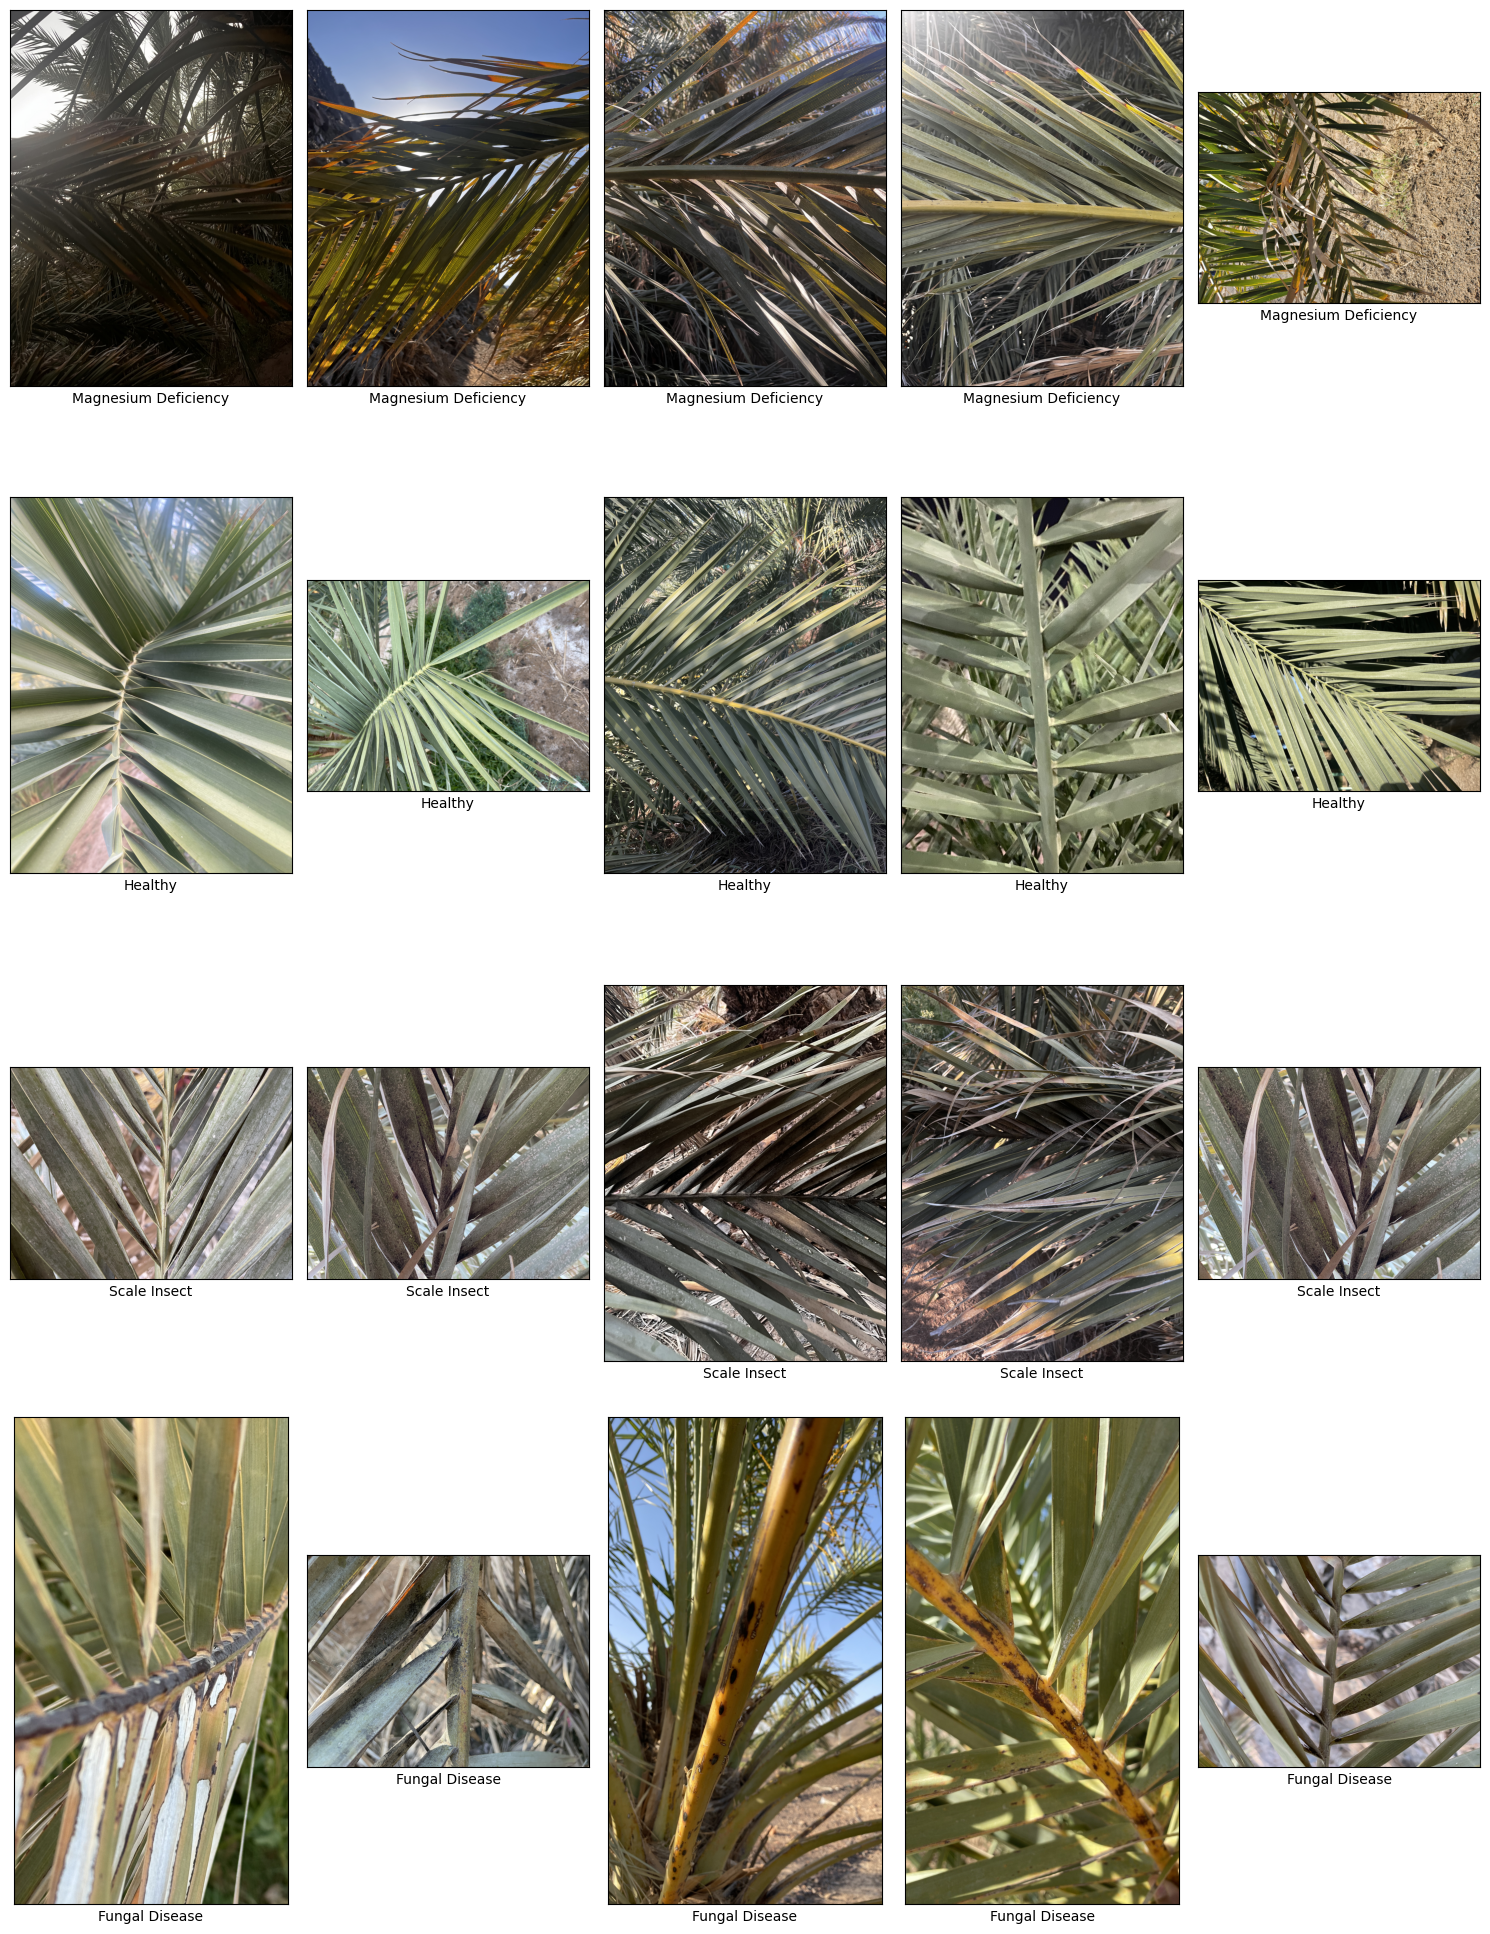

In [6]:
# Membuat dictionary untuk menyimpan gambar untuk setiap kelas dalam data
palm_disease_image = {}

# Menentukan path sumber dataset

# Hapus komentar pada kode ini jika menggunakan Kaggle Notebook
source_path = "/kaggle/working/palm-disease-dataset/"

# Hapus komentar pada kode ini jika menggunakan lokal device atau Google Colab
#source_path = "/dataset/palm-disease-dataset/"

for i in os.listdir(source_path):
    palm_disease_image[i] = os.listdir(source_path + i)

# menampilkan secara acak 5 gambar untuk masing-masing kelas
fig, ax = plt.subplots(4, 5, figsize=(15, 20))

for i, label in enumerate(os.listdir(source_path)):
    images = np.random.choice(palm_disease_image[label], 5, replace=False)
    for j, image in enumerate(images):
        img_path = os.path.join(source_path, label, image)
        img = Image.open(img_path)
        ax[i, j].imshow(img)
        ax[i, j].set(xlabel=label, xticks=[], yticks=[])

fig.tight_layout()

In [7]:
# Membuat fungsi untuk melihat jumlah image tiap-tiap kelas
def get_image_count(path):
    image_count = {}
    for label in os.listdir(path):
        image_count[label] = len(os.listdir(os.path.join(path, label)))
    return image_count


print(get_image_count(source_path))

{'Magnesium Deficiency': 55, 'Healthy': 41, 'Scale Insect': 80, 'Fungal Disease': 53}


### **Distribution Plot of Class Dataset**

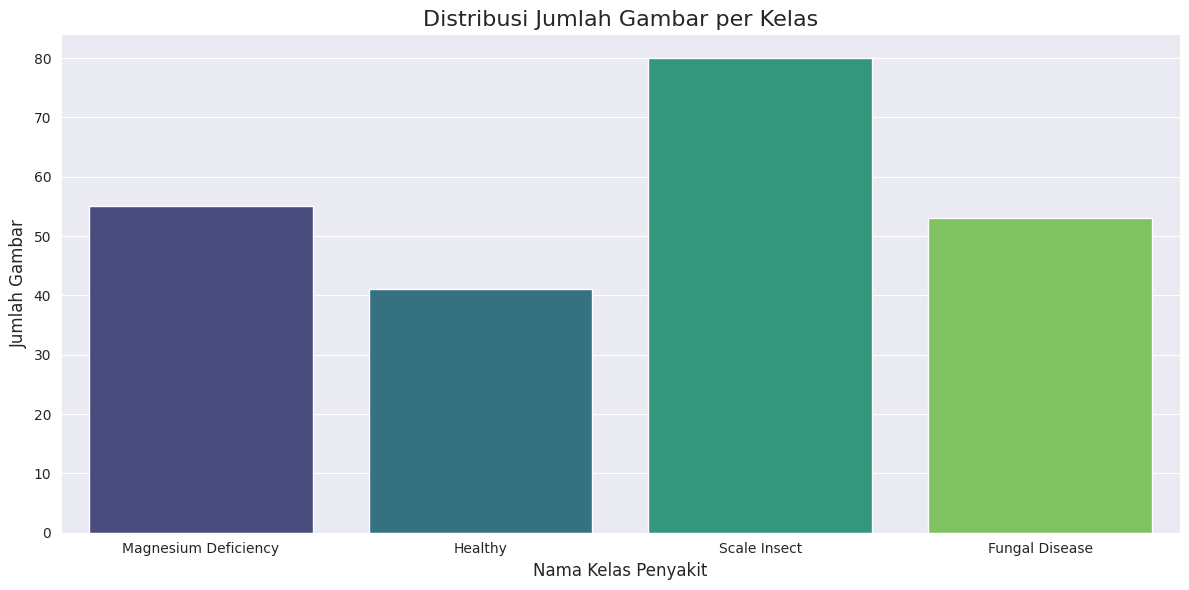

In [8]:
def plot_distribution(path):
    # Membuat daftar yang menyimpan data untuk setiap nama file, path file, dan label dalam data
    file_name = []
    labels = []
    full_path = []

    # Mendapatkan nama file gambar, path file, dan label satu per satu dengan looping, dan simpan sebagai DataFrame
    for path, subdirs, files in os.walk(path):
        for name in files:
            file_name.append(name)
            labels.append(path.split('/')[-1])
            full_path.append(os.path.join(path, name))

    distribution_train = pd.DataFrame({
        'path': full_path,
        'file_name': file_name,
        'labels': labels
    })
    for name in files:
        file_name.append(name)
        labels.append(path.split('/')[-1])

    # Plot distribusi gambar setiap kelas
    plt.figure(figsize=(12, 6))
    sns.set_style('darkgrid')
    sns.countplot(data=distribution_train, x='labels', palette='viridis')

    plt.title("Distribusi Jumlah Gambar per Kelas", fontsize=16)
    plt.xlabel("Nama Kelas Penyakit", fontsize=12)
    plt.ylabel("Jumlah Gambar", fontsize=12)
    plt.tight_layout()
    plt.show()


plot_distribution(source_path)

## **Preprocessing Data**


### **Augmentation Data**

In [9]:
# Membuat fungsi untuk melakukan rotasi berlawanan arah jarum jam
def anticlockwise_rotation(img):
    img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
    img = cv2.resize(img, (224, 224))
    angle = random.randint(0, 180)
    return rotate(img, angle)


# Membuat fungsi untuk melakukan rotasi searah jarum ram
def clockwise_rotation(img):
    img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
    img = cv2.resize(img, (224, 224))
    angle = random.randint(0, 180)
    return rotate(img, -angle)


# Membuat fungsi untuk memberikan efek peningkatan kecerahan pada gambar
def add_brightness(img):
    img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
    img = cv2.resize(img, (224, 224))
    img = adjust_gamma(img, gamma=0.5, gain=1)
    return img


# Membuat fungsi untuk membalik gambar secara vertikal dari atas ke bawah
def flip_up_down(img):
    img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
    img = cv2.resize(img, (224, 224))
    return np.flipud(img)


# Membuat fungsi untuk memberikan efek pergeseran acak pada gambar
def sheared(img):
    img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
    img = cv2.resize(img, (224, 224))
    transform = AffineTransform(shear=0.2)
    shear_img = warp(img, transform, mode='wrap')
    return shear_img


# Membuat fungsi untuk melakukan pergeseran melengkung pada gambar
def warp_shift(img):
    img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
    img = cv2.resize(img, (224, 224))
    transform = AffineTransform(translation=(0, 40))
    warp_img = warp(img, transform, mode='wrap')
    return warp_img

In [10]:
# Membuat varabel transofrmasi yang akan menyimpan semua proses pra-pemrosesan yang telah dilakukan sebelumnya
transformations = {
    'anticlockwise_rotation': anticlockwise_rotation,
    'clockwise_rotation': clockwise_rotation,
    'add_brightness': add_brightness,
    'flip_up_down': flip_up_down,
    'shear_image': sheared,
    'warp_shift': warp_shift
}


def generate_augmented_image(image_class_name, source_image_path, num_augmented_images):
    img_processed_path = os.path.join(source_image_path, image_class_name)

    processed_images = []

    for img in os.listdir(img_processed_path):
        processed_images.append(os.path.join(img_processed_path, img))

    images_to_generate = num_augmented_images - len(os.listdir(img_processed_path))

    i = 1

    while i <= images_to_generate:
        random_image = random.choice(processed_images)

        try:
            original_image = io.imread(random_image)
            transformed_image = None

            num_transformations_to_apply = random.randint(1, len(transformations))

            num_transformations = 0

            while num_transformations <= num_transformations_to_apply:
                key = random.choice(list(transformations))
                transformed_image = transformations[key](original_image)
                num_transformations += 1

            new_image_path = "%s/augmented_image_%s.jpg" % (img_processed_path, i)
            transformed_image = img_as_ubyte(transformed_image)
            cv2.imwrite(new_image_path, transformed_image)
            i += 1
        except Exception as e:
            print('Could not read the', image, ':', e, 'hence skipping it.')

In [11]:
source_path = '/kaggle/working/palm-disease-dataset/'

for label in list_label:
    generate_augmented_image(label, source_path, 500)

print("Berhasil melakukan augmentasi gambar")

Berhasil melakukan augmentasi gambar


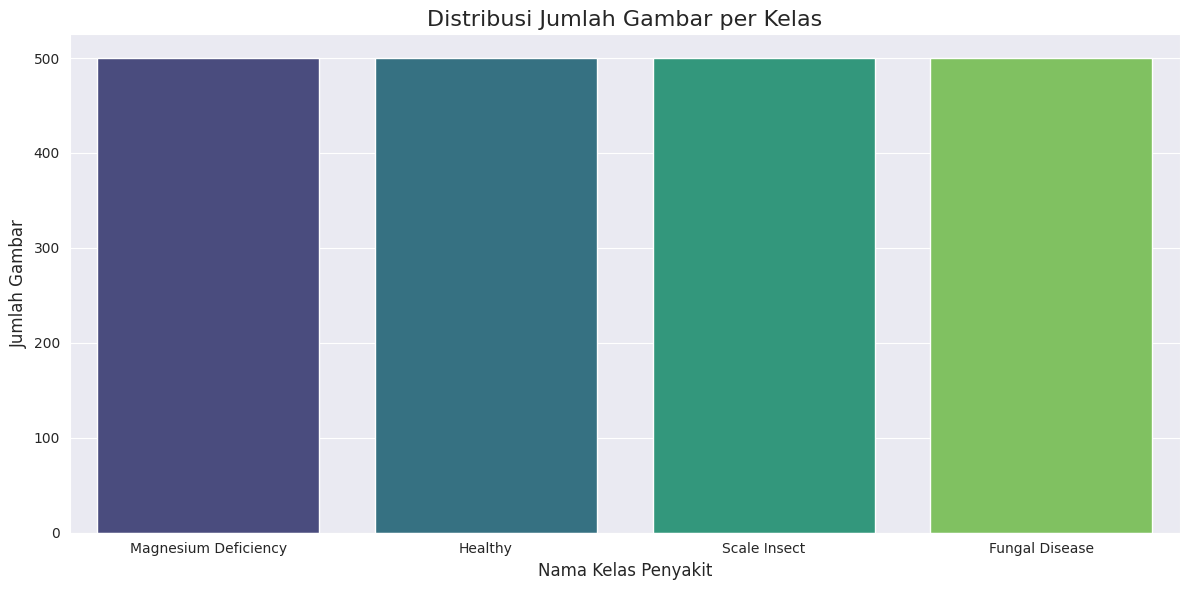

In [12]:
# Melihat plot distribusi kelas setelah dilakukan augmentasi
plot_distribution(source_path)

### **Spliting Data**

In [13]:
# Membuat variabel untuk menampung lokasi folder dari dataset gambar

# Hapus komentar pada kode ini jika menggunakan Google Colab atau lokal device
#source_path = '/dataset/palm-disease-dataset/'

# Hapus komentar pada kode ini jika menggunakan Kaggle Notebook
source_path = '/kaggle/working/palm-disease-dataset/'

file_name = []
labels = []
full_path = []

for path, subdirs, files in os.walk(source_path):
    for name in files:
        file_name.append(name)
        labels.append(path.split('/')[-1])
        full_path.append(os.path.join(path, name))

# Memasukkan variabel yang sudah dikumpulkan pada looping di atas menjadi sebuah DataFrame
image_df = pd.DataFrame({
    'file_name': file_name,
    'labels': labels,
    'full_path': full_path
})

# Melihat jumlah data gambar pada masing-masing label
image_df['labels'].value_counts()

labels
Magnesium Deficiency    500
Healthy                 500
Scale Insect            500
Fungal Disease          500
Name: count, dtype: int64

In [14]:
# variabel yang digunaka pada pemisahan data ini, di mana variabel x = data path dan y = data labels
X = image_df['full_path']
y = image_df['labels']

# Split dataset awal menjadi data train dan temp (test dan validasi)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

# Menyatukan ke dalam maisng-masing DataFrame
df_train = pd.DataFrame({
    'path': X_train,
    'labels': y_train,
    'set': 'train'
})

df_validation = pd.DataFrame({
    'path': X_val,
    'labels': y_val,
    'set': 'validation'
})

df_test = pd.DataFrame({
    'path': X_test,
    'labels': y_test,
    'set': 'test'
})

# Menggabungkan DataFrame df_train, df_test, dan df_validation
df_all = pd.concat([df_train, df_validation, df_test], ignore_index=True)
print(df_all.groupby(['set', 'labels']).size())

set         labels              
test        Fungal Disease           75
            Healthy                  75
            Magnesium Deficiency     75
            Scale Insect             75
train       Fungal Disease          350
            Healthy                 350
            Magnesium Deficiency    350
            Scale Insect            350
validation  Fungal Disease           75
            Healthy                  75
            Magnesium Deficiency     75
            Scale Insect             75
dtype: int64


In [15]:
# Mengecek sampel data
print(df_all.sample(5))

                                                   path                labels  \
702   /kaggle/working/palm-disease-dataset/Magnesium...  Magnesium Deficiency   
1346  /kaggle/working/palm-disease-dataset/Magnesium...  Magnesium Deficiency   
536   /kaggle/working/palm-disease-dataset/Scale Ins...          Scale Insect   
1598  /kaggle/working/palm-disease-dataset/Fungal Di...        Fungal Disease   
1991  /kaggle/working/palm-disease-dataset/Healthy/a...               Healthy   

             set  
702        train  
1346       train  
536        train  
1598  validation  
1991        test  


In [16]:
# Memanggil dataset asli yang berisi keseluruhan data gambar yang sesuai dengan labelnya

# Hapus komentar pada kode ini jika menggunakan Google Colab atau lokal device
#datasource_path = 'dataset/palm-disease-dataset/'

# Hapus komentar pada kode ini jika menggunakan Kaggle Notebook
datasource_path = '/kaggle/working/palm-disease-dataset/'

# Membuat variabel dataset, tempat menampung data yang telah dilakukan splitting

# Hapus komentar pada kode ini jika menggunakan Google Colab atau lokal device
#dataset_path = 'dataset/final-dataset/'

# Hapus komentar pada kode ini jika menggunakan Kaggle Notebook
dataset_path = '/kaggle/working/final-dataset/'

for index, row in tq(df_all.iterrows()):
    file_path = row['path']

    if os.path.exists(file_path) == False:
        file_path = os.path.join(datasource_path, row['labels'], row['image'].split('.')[0])

    # Membuat direktori tujuan folder
    if os.path.exists(os.path.join(dataset_path, row['set'], row['labels'])) == False:
        os.makedirs(os.path.join(dataset_path, row['set'], row['labels']))

    # Menentukan tujuan file
    destination_file_name = file_path.split('/')[-1]
    destination_path = os.path.join(dataset_path, row['set'], row['labels'], destination_file_name)

    # Memindahkan file ke direktori tujuan
    if os.path.exists(destination_path) == False:
        shutil.copy2(file_path, destination_path)

0it [00:00, ?it/s]

### **Image Data Generator**

In [17]:
# Mendefinisikan direktori daset training, test, dan validation

# Hapus komentar pada kode di bawah ini jika menggunakan Google Colab atau device lokal
# TRAIN_DIR = "dataset/final-dataset/train"
# TEST_DIR = "dataset/final-dataset/test"
# VAL_DIR = "dataset/final-dataset/validation"

# Hapus komentar pada kode di bawah ini jika menggunakan Kaggle Notebook
TRAIN_DIR = '/kaggle/working/final-dataset/train'
TEST_DIR = '/kaggle/working/final-dataset/test'
VAL_DIR = '/kaggle/working/final-dataset/validation'


# Membuat fungsi untuk menampilkan jumlah data train berdasarkan label
def print_total_train_data(label):
    train_temp = os.path.join(TRAIN_DIR, label)
    train_count = len(os.listdir(train_temp))
    print("Total train data for {} is {}".format(label, train_count))


# Membuat fungsi untuk menampilkan jumlah data test berdasarkan label
def print_total_test_data(label):
    test_temp = os.path.join(TEST_DIR, label)
    test_count = len(os.listdir(test_temp))
    print("Total test data for {} is {}".format(label, test_count))


# Membuat fungsi untuk menampilkan jumlah data validation berdasarkan label
def print_total_validation_data(label):
    val_temp = os.path.join(VAL_DIR, label)
    val_count = len(os.listdir(val_temp))
    print("Total validation data for {} is {}".format(label, val_count))


for label in list_label:
    print_total_train_data(label)
    print_total_test_data(label)
    print_total_validation_data(label)
    print("\n")

Total train data for Magnesium Deficiency is 350
Total test data for Magnesium Deficiency is 75
Total validation data for Magnesium Deficiency is 75


Total train data for Healthy is 350
Total test data for Healthy is 75
Total validation data for Healthy is 75


Total train data for Scale Insect is 350
Total test data for Scale Insect is 75
Total validation data for Scale Insect is 75


Total train data for Fungal Disease is 350
Total test data for Fungal Disease is 75
Total validation data for Fungal Disease is 75




In [18]:
# Membuat objek ImageDataGeneratir untuk menormalisasikan gambar
train_datagen = ImageDataGenerator(rescale=1. / 255)
test_datagen = ImageDataGenerator(rescale=1. / 255)
val_datagen = ImageDataGenerator(rescale=1. / 255)

IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32
SEED = 42

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    seed=SEED,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

validation_generator = val_datagen.flow_from_directory(
    VAL_DIR,
    seed=SEED,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    seed=SEED,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 1400 images belonging to 4 classes.
Found 300 images belonging to 4 classes.
Found 300 images belonging to 4 classes.


## **Building Model**

### **Model Experiment 1**

In [32]:
# Inisialisasi model sekuensial
model_1 = Sequential()

model_1.add(Input(shape=(224, 224, 3)))

model_1.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
model_1.add(BatchNormalization())
model_1.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
model_1.add(MaxPooling2D(pool_size=(2, 2)))

model_1.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
model_1.add(BatchNormalization())
model_1.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
model_1.add(MaxPooling2D(pool_size=(2, 2)))

model_1.add(Conv2D(256, (3, 3), activation='relu', padding='same'))
model_1.add(BatchNormalization())
model_1.add(Conv2D(256, (3, 3), activation='relu', padding='same'))
model_1.add(MaxPooling2D(pool_size=(2, 2)))

model_1.add(GlobalAveragePooling2D())

model_1.add(Dense(256, activation='relu'))
model_1.add(Dropout(0.5))

model_1.add(Dense(len(list_label), activation='softmax'))

opt = Adam(learning_rate=0.0001)

model_1.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

# rangkuman arsitektur model
model_1.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)                   │ (None, 224, 224, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_9                │ (None, 224, 224, 64)        │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_19 (Conv2D)                   │ (None, 224, 224, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_9 (MaxPooling2D)       │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_20 (Conv2D)                   │ (None, 112, 112, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_10               │ (None, 112, 112, 128)       │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_21 (Conv2D)                   │ (None, 112, 112, 128)       │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_10 (MaxPooling2D)      │ (None, 56, 56, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_22 (Conv2D)                   │ (None, 56, 56, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_11               │ (None, 56, 56, 256)         │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_23 (Conv2D)                   │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_11 (MaxPooling2D)      │ (None, 28, 28, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_3           │ (None, 256)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 256)                 │          65,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 4)                   │           1,028 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,214,020 (4.63 MB)

 Trainable params: 1,213,124 (4.63 MB)

 Non-trainable params: 896 (3.50 KB)

In [33]:
# Membuat callback
checkpoint = ModelCheckpoint('model_1.h5', monitor='val_loss', save_best_only=True, mode='min')


# Membuat custom callback
class EpochCheckpoint(Callback):
    def on_epoch_end(self, epoch, logs={}):
        if (logs.get('accuracy') > 0.95):
            print("[INFO] Reached 95% accuracy, stopping training")
            self.model.stop_training = True


epoch_checkpoint = EpochCheckpoint()

In [34]:
# Fitting / training model
history_model_1 = model_1.fit(
    train_generator,
    epochs=50,
    validation_data=validation_generator,
    callbacks=[checkpoint, epoch_checkpoint]
)

Epoch 1/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 77s 2s/step - accuracy: 0.3732 - loss: 1.4511 - val_accuracy: 0.2500 - val_loss: 1.3988
Epoch 2/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 24s 539ms/step - accuracy: 0.5385 - loss: 1.0853 - val_accuracy: 0.2500 - val_loss: 1.4196
Epoch 3/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 25s 563ms/step - accuracy: 0.6260 - loss: 0.9045 - val_accuracy: 0.2500 - val_loss: 1.4344
Epoch 4/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 23s 522ms/step - accuracy: 0.6491 - loss: 0.8269 - val_accuracy: 0.2500 - val_loss: 1.6091
Epoch 5/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 23s 522ms/step - accuracy: 0.7008 - loss: 0.7526 - val_accuracy: 0.2500 - val_loss: 1.7109
Epoch 6/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 24s 547ms/step - accuracy: 0.7216 - loss: 0.6921 - val_accuracy: 0.2500 - val_loss: 2.5910
Epoch 7/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 23s 514ms/step - accuracy: 0.7355 - loss: 0.6740 - val_accuracy: 0.2500 - val_loss: 3.4339
Epoch 8/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 24s 541ms/step - accuracy: 0.7638 - loss: 0.5832 - val_accurac

### **Model Experiment 2**

### **Model Experiment 3**

### **Model Transfer Learning**

In [ ]:
# Melakukan inisiasi model dasar
base_model_tl = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Melakukan frezze pada model dasar
base_model_tl.trainable = False

# Membuat model baru
inputs = Input(shape=(224, 224, 3))
x = base_model_tl(inputs, training=False)
x = GlobalAveragePooling2D()(x)
outputs = Dense(len(list_label), activation='softmax')(x)

model_tl = Model(inputs, outputs)

# Melatih model MobileNetV2 dengan data baru
model_tl.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
history_model_tl = model_tl.fit(train_generator, epochs=50, validation_data=validation_generator,
                                callbacks=[checkpoint, epoch_checkpoint])

## **Evaluating Model**

### **Evaluating Model 1**

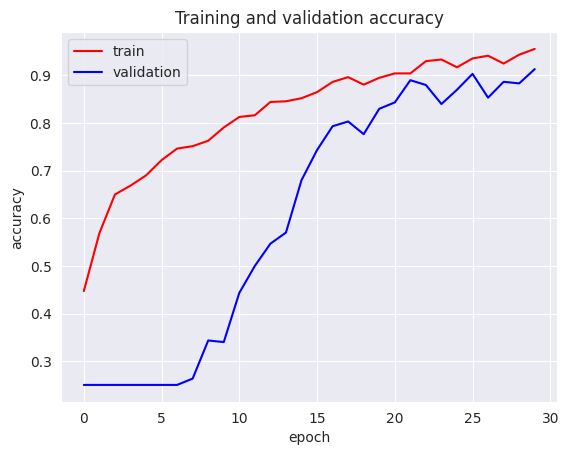

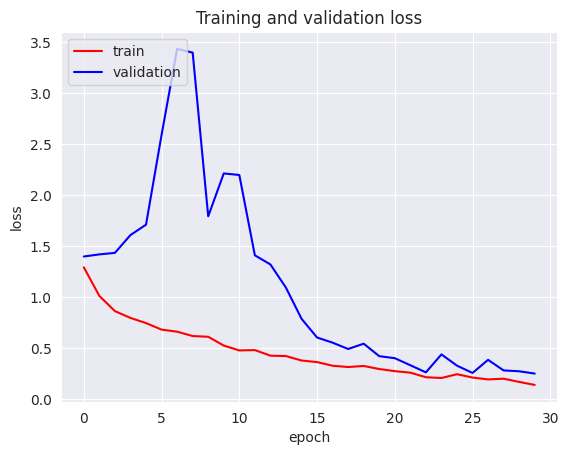

In [35]:
acc_1 = history_model_1.history['accuracy']
val_acc_1 = history_model_1.history['val_accuracy']
loss_1 = history_model_1.history['loss']
val_loss_1 = history_model_1.history['val_loss']

epochs = range(len(acc_1))


def plot_model_result(epochs, acc, val_acc, loss, val_loss):
    plt.plot(epochs, acc, 'r')
    plt.plot(epochs, val_acc, 'b')
    plt.title('Training and validation accuracy')
    plt.ylabel('accuracy')
    plt.xlabel('epoch')
    plt.legend(['train', 'validation'], loc='upper left')
    plt.show()

    plt.plot(epochs, loss, 'r')
    plt.plot(epochs, val_loss, 'b')
    plt.title('Training and validation loss')
    plt.ylabel('loss')
    plt.xlabel('epoch')
    plt.legend(['train', 'validation'], loc='upper left')
    plt.show()


plot_model_result(epochs, acc_1, val_acc_1, loss_1, val_loss_1)

In [36]:
# Evaluasi model menggunakan data pengujian
evaluation_model_1 = model_1.evaluate(test_generator)

# Menampilkan hasil evaluasi
print('Test Loss:', evaluation_model_1[0])
print('Test Accuracy:', evaluation_model_1[1])

10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 320ms/step - accuracy: 0.8601 - loss: 0.3484
Test Loss: 0.3010077476501465
Test Accuracy: 0.8833333253860474


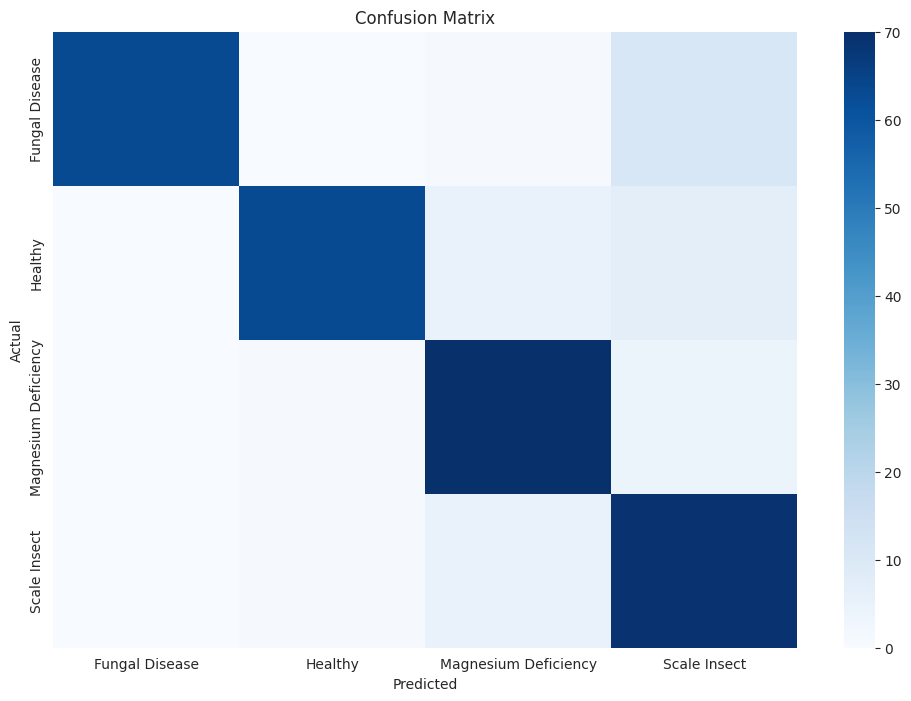

In [37]:
test_generator.reset()

preds_1 = model_1.predict(test_generator, verbose=0)
y_pred = preds_1.argmax(axis=1)
y_true = test_generator.classes

class_names = list(test_generator.class_indices.keys())

# Menampilkan confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

In [39]:
# Menampilkan classification report
print(classification_report(y_true, y_pred, target_names=class_names))

                      precision    recall  f1-score   support

      Fungal Disease       1.00      0.84      0.91        75
             Healthy       0.97      0.84      0.90        75
Magnesium Deficiency       0.86      0.93      0.90        75
        Scale Insect       0.76      0.92      0.83        75

            accuracy                           0.88       300
           macro avg       0.90      0.88      0.89       300
        weighted avg       0.90      0.88      0.89       300



### **Evaluating Model 2**

### **Evaluating Model 3**

### **Evaluating Model Transfer Learning**

## **Converting Model**

### Converting Model to SavedModel format

In [41]:
# Konversi model ke format SavedModel

# Hapus komentar pada kode ini jika menggunakan Google Colab atau lokal device
#saved_path = '/model/saved_model'

# Hapus komentar pad akode ini jika menggunakan Kaggle Notebook
saved_path = '/kaggle/working/model/saved_model'

save(model_1, saved_path)

### Converting SavedModel to ZIP (Kaggle Notebook)

In [55]:
model_folder_name = "model/saved_model"
saved_model_path = "/kaggle/working/model/saved_model/"

zip_file_name = "palm-oil-model.zip"
zip_file_path = os.path.join("/kaggle", "working", zip_file_name)

if os.path.exists(saved_model_path):
    print(f"Mengkompres folder '{saved_model_path}' menjadi '{zip_file_name}'")

    working_dir = os.getcwd()
    os.chdir(saved_model_path)

    try:
        !zip -r {zip_file_name} .
        print(f"Berhasil mengkompres model ke: {zip_file_path}")

        # Membuat link download
        display(FileLink(zip_file_name))
    except Exception as e:
        print(f"Unexpected error: {e}")
    finally:
        os.chdir(working_dir)

else:
    print(f"Error: folder model '{model_folder_name}' tidak ditemukan di '{saved_model_path}'")

Mengkompres folder '/kaggle/working/model/saved_model/' menjadi 'palm-oil-model.zip'
  adding: saved_model.pb (deflated 89%)
  adding: variables/ (stored 0%)
  adding: variables/variables.index (deflated 69%)
  adding: variables/variables.data-00000-of-00001 (deflated 8%)
  adding: fingerprint.pb (stored 0%)
  adding: assets/ (stored 0%)
Berhasil mengkompres model ke: /kaggle/working/palm-oil-model.zip


/kaggle/working/model/saved_model/palm-oil-model.zip

## **Inferring Model**

### **Create Inference Model**

In [4]:
# Path ke model SavedModel

# Hapus komentar pada kode ini jika menggunakan Google Colab atau lokal device
#model_path = 'model/saved_model'

# Hapus komentar pada kode ini jika menggunakan Kaggle Notebook
model_path = "/kaggle/input/palm-oil-model/keras/default/1/saved_model"


# Load model
def load_saved_model_with_tfsm(model_path):
    if not os.path.exists(model_path):
        print(f"Error: Folder SavedModel tidak ditemukan di: {model_path}")

    loaded_model_tfsm = None
    try:
        print("Memuat model SavedModel menggunakan TFSM Layer..")
        loaded_model_tfsm = TFSMLayer(model_path, call_endpoint='serving_default')
        print("Model berhasil dimuat")

        return loaded_model_tfsm
    except Exception as e:
        print(f"Gagal memuat model SavedModel dengan TFSM layer: {e}")


# Membuat model Keras baru menggunakan layer TFSM untuk inferring
def create_model_with_tfsm(model_tfsm):
    input_layer = Input(shape=(224, 224, 3))
    output_layer = model_tfsm(input_layer)

    inference_model = Model(inputs=input_layer, outputs=output_layer)
    print("Model inferensi berhasil dibuat")
    return inference_model


model_1_inf = load_saved_model_with_tfsm(model_path)
model_1_inf = create_model_with_tfsm(model_1_inf)

# Melihat ringkasan dari arsitektur model
model_1_inf.summary()

Memuat model SavedModel menggunakan TFSM Layer..
Model berhasil dimuat
Model inferensi berhasil dibuat


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ tfsm_layer_1 (TFSMLayer)             │ (None, 4)                   │       1,214,020 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,214,020 (4.63 MB)

 Trainable params: 1,213,124 (4.63 MB)

 Non-trainable params: 896 (3.50 KB)

### **Preprocessing Predict Image**

In [50]:
list_label = ['Fungal Disease', 'Healthy', 'Magnesium Deficiency', 'Scale Insect']


# Membuat fungsi untuk menampilkan gambar yang akan diprediski
def show_image(img_predict_path):
    img = image.load_img(img_predict_path, target_size=(224, 224))
    plt.imshow(img)
    plt.axis("off")
    plt.title("Image Input")
    plt.show()


# Memproses gambar inputan menjadi matriks
def preprocessing_img(img_predict_path):
    img = image.load_img(img_predict_path, target_size=(224, 224))

    img_array = image.img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    img_tensor = tf.constant(img_array, dtype=tf.float32)

    return img_tensor


# Membuat fungsi untuk melakukan prediksi
def predict_img(inferring_model, img_predict_path):
    predict = inferring_model.predict(preprocessing_img(img_predict_path))
    predicted_class = tf.argmax(predict['output_0'], axis=1).numpy()[0]

    single_img_probably = predict['output_0'][0]

    predicted_class_index = np.argmax(single_img_probably)

    class_probably_list = []
    for i, prob in enumerate(single_img_probably):
        class_probably_list.append((list_label[i], prob))

    class_probably_sorted = sorted(class_probably_list, key=lambda x: x[1], reverse=True)
    for class_name, prob in class_probably_sorted:
        print(f"- {class_name}: {prob * 100:.2f}%")

    predicted_class_name = class_probably_sorted[0][0]
    confidence = class_probably_sorted[0][1] * 100

    print(f"\nGambar paling cocok dengan kelas: {predicted_class_name}")
    print(f"Confidence: {confidence:.2f}%")


print(list_label)

['Fungal Disease', 'Healthy', 'Magnesium Deficiency', 'Scale Insect']


### **Download Predict Image from Google Drive**

In [11]:
# Mengunduh gambar prediksi dari Google Drive
file_predict_id = "1NKZ9KwIaX5OM04WnlJILV3Vm1JUfp7OL"
url_predict = f"https://drive.google.com/uc?id={file_predict_id}"
gdown.download(url_predict, quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1NKZ9KwIaX5OM04WnlJILV3Vm1JUfp7OL
To: /kaggle/working/predict-img-test.zip
100%|██████████| 917k/917k [00:00<00:00, 109MB/s]


'predict-img-test.zip'

In [13]:
# Unzip berkas yang telah diunduh dari Google Drive
with zipfile.ZipFile('predict-img-test.zip', 'r') as zip_file:
    zip_file.extractall()

print("Berhasil melakukan unzip")

### **Inferring Model**

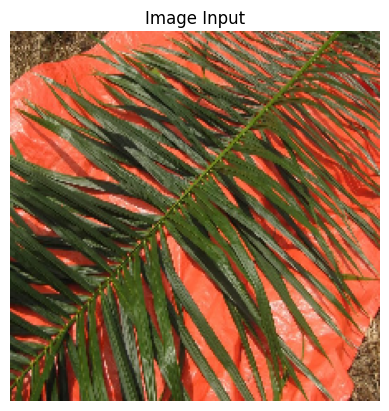

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
- Scale Insect: 97.43%
- Healthy: 2.57%
- Magnesium Deficiency: 0.00%
- Fungal Disease: 0.00%

Gambar paling cocok dengan kelas: Scale Insect
Confidence: 97.43%


In [51]:
# Menampilkan gambar prediksi
img_predict_1 = "Predict Image Test/Healthy.png"
show_image(img_predict_1)

# Melakukan prediksi
predict_result_1 = predict_img(model_1_inf, img_predict_1)

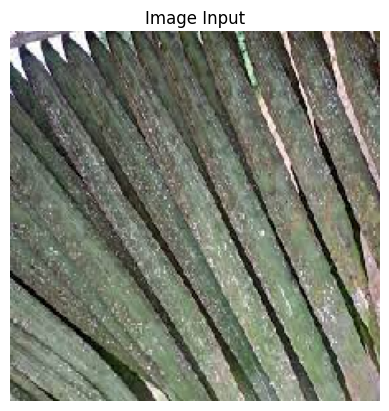

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
- Scale Insect: 58.98%
- Healthy: 39.39%
- Magnesium Deficiency: 1.25%
- Fungal Disease: 0.37%

Gambar paling cocok dengan kelas: Scale Insect
Confidence: 58.98%


In [52]:
# Menampilkan gambar prediksi
img_predict_2 = "Predict Image Test/Fungal Disease.jpeg"
show_image(img_predict_2)

# Melakukan prediksi
predict_result_2 = predict_img(model_1_inf, img_predict_2)

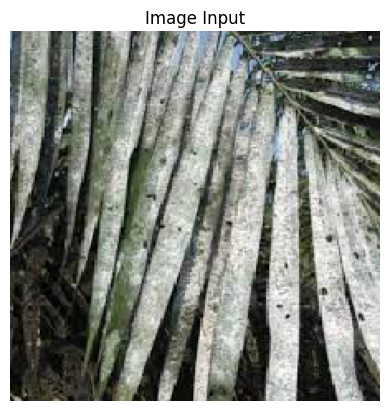

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
- Scale Insect: 99.09%
- Healthy: 0.82%
- Fungal Disease: 0.09%
- Magnesium Deficiency: 0.00%

Gambar paling cocok dengan kelas: Scale Insect
Confidence: 99.09%


In [53]:
# Menampilkan gambar prediksi
img_predict_3 = "Predict Image Test/Scale Insect.jpeg"
show_image(img_predict_3)

# Melakukan prediksi
predict_result_3 = predict_img(model_1_inf, img_predict_3)

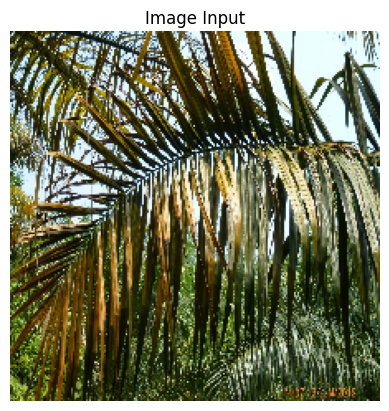

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
- Healthy: 99.97%
- Magnesium Deficiency: 0.03%
- Scale Insect: 0.00%
- Fungal Disease: 0.00%

Gambar paling cocok dengan kelas: Healthy
Confidence: 99.97%


In [55]:
# Menampilkan gambar prediksi
img_predict_4 = "Predict Image Test/Magnesium Deficiency.jpg"
show_image(img_predict_4)

# Melakukan prediksi
predict_result_4 = predict_img(model_1_inf, img_predict_4)